#  과제 문제

## 1. 과제 목표
- Housing 데이터 분석 리포트 작성
- 수업시간에 배운 데이터 분석 기법 활용  

---

## 2. 제출 내용

### 1) 분석 코드
- Python을 활용한 데이터 분석 코드 작성  
- 결측치 제거, 통계 분석 및 시각화, 데이터 스케일링, 회귀 분석, 규제 기법, Grid search, CV 등 활용

### 2) 분석 리포트
- 데이터 설명 (데이터 수, 변수 설명 - 각 변수의 의미, 데이터 타입 등)  
- 분석 코드 설명  
- 분석 결과 및 결론 설명 (통계분석, 선형회귀분석 등 결과 해석)  
- 결론 설명(결과 해석을 바탕으로 본인 의견 작성)  


In [2]:
# Housing Data 의 분석
# 14개의 열 존재
# CRIM	ZN	INDUS  CHAS	 NOX  RM  AGE	DIS	 RAD  TAX	PTRATIO B	 LSTAT	 MEDV
# MEDV 즉 주택가격을 예측하는 회귀 문제

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns


# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


# Housing 데이터 정보 및 결측치 제거

# 1-1. 데이터 읽기 확인

In [ ]:
# 데이터 불러오기
df = pd.read_csv("data/HousingData.csv")

print("Housing 데이터: ",  df.shape)
df.columns
df.info()
df.describe()

# 14개의 열, 506개의 행
# CRIM	ZN	INDUS  CHAS	 NOX  RM  AGE	DIS	 RAD  TAX	PTRATIO B LSTAT	 MEDV
# MEDV 주택가격 예측 회귀 문제
# CRIM(지역 범죄율), ZN(대규모 주거지역 비율), INDUS(비상업지역 비율), CHAS(찰스강 인접 여부), NOX(질소산화물 농도), RM(평균 방 개수), 
# AGE(노후 주택 비율), DIS(고용센터까지 거리), RAD(고속도로 접근성 지수), TAX(재산세율), PTRATIO(학생-교사 비율), B(흑인 비율), 
# LSTAT(저소득층 비율), MEDV(주택 중간가격)


Housing 데이터:  (506, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


# 1-2. 데이터 결측치 제거

In [79]:
# 결측치 확인
print(df.isnull().sum())

# 데이터 결측치 제거
df = df.dropna()
print("남은 결측치 수: ", df.isnull().sum())
# 행이 506개에서 394개로 줄어듦


CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64
남은 결측치 수:  CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


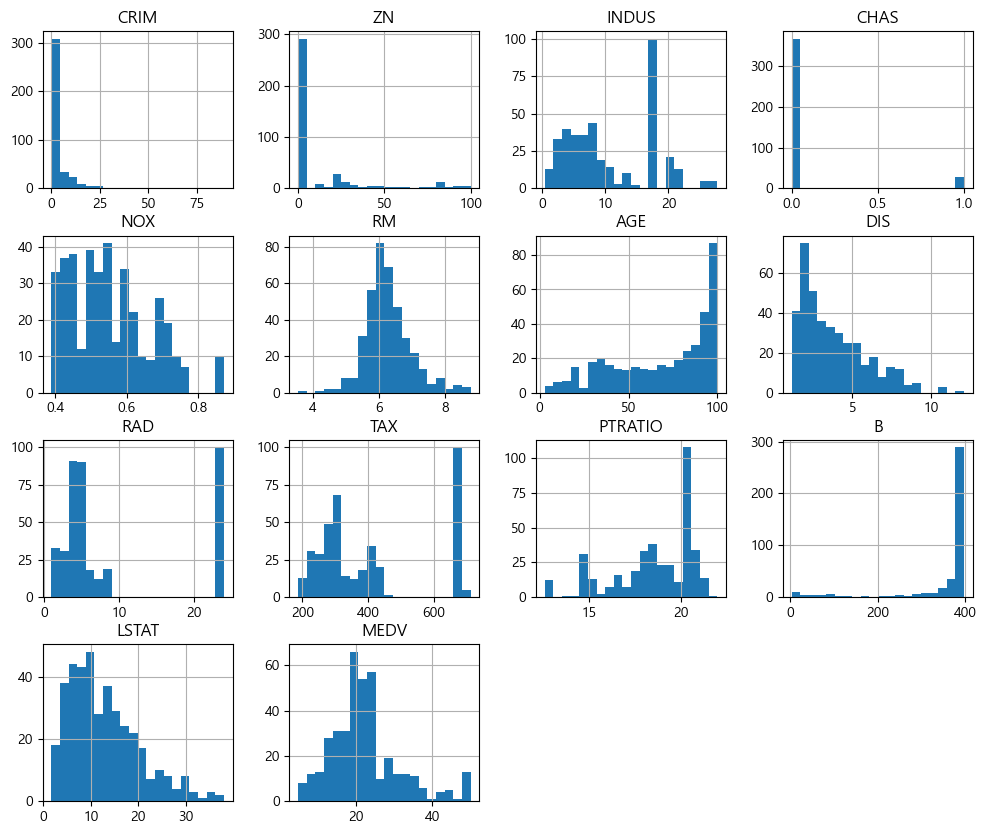

In [80]:
# 데이터의 자료형 변환 작업
df["CHAS"] = df["CHAS"].astype(int)

df.hist(bins=20, figsize=(12,10))
plt.show()

# 1-3. 데이터 셋 Train, Test 분리

In [81]:
# Housing 데이터 셋 Train, Test 분리
x = df.drop(columns = ["MEDV"]).astype(float)  # 독립 변수
y = df['MEDV']               # 종속 변수

# 데이터 분리 8:2
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)   

# statsmodels OLS를 위해 상수항 추가        OLS는 상수항을 자동으로 넣지 않음  y = a + bx1 + bx2 + ...
x_train_sm = sm.add_constant(x_train)
x_test_sm = sm.add_constant(x_test)

In [82]:
ols_origin = sm.OLS(y_train, x_train_sm).fit()   # OLS 모델 생성
print(ols_origin.summary())                     # 모델 요약 출력

# 성능평가
y_pred = ols_origin.predict(x_test_sm)          # 테스트 데이터에 대한 예측 수행
rmse_ols_origin = np.sqrt(np.mean((y_test - y_pred) ** 2))  # RMSE 계산
r2_ols_origin = 1 - np.sum((y_test - y_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)  # R² 계산

print(f"RMSE: {rmse_ols_origin:.4f}")
print(f"R²: {r2_ols_origin:.4f}")


# rmse_ols_origin
# r2_ols_origin

# OLS 모델 결과
# R-squared(R2):                       0.798        R제곱값
# Adj. R-squared:                      0.789        독립변수 수를 고려한 R제곱값
# F value:                             91.24        F통계량
# AIC, BIC:                            1809. 1861.  변수 선택지표로 값이 작을수록 좋은 모델
# 모델 적합도를 평가함
# coef: 회귀계수 각 독립변수가 종속변수에 미치는 영향                      
# std err: 표준오차 회귀계수가 얼마나 불확실한가: 작을수록 좋음
# t-통계량: 해당 변수가 종속변수에 얼마나 유의미한가: 절대값이 클수록 좋음
# P>|t|: p-value 해당 변수가 종속변수에 유의미한가: 0.05보다 작을수록 좋음
# 0.05보다 작으면 유의마 적울수록 좋음
# [ 0.025  0.975]: 회귀계수의 95% 신뢰구간
# dis, rm


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     91.24
Date:                Mon, 13 Oct 2025   Prob (F-statistic):           4.14e-96
Time:                        19:59:06   Log-Likelihood:                -890.32
No. Observations:                 315   AIC:                             1809.
Df Residuals:                     301   BIC:                             1861.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.6524      5.913      5.691      0.0

# 2. 데이터 스케일링

# 2-1. 데이터 스케일링의 테스트

In [84]:
# 테스트 데이터 스케일링
df2 = df.copy()

# min-max 스케일링
for col in ["DIS", "AGE"]:
    df2[col] = (df2[col] - df2[col].min()) / (df2[col].max() - df2[col].min())

# 로그변환
for col in ["CRIM", "DIS", "LSTAT"]:
    df2[col] = np.log1p(df2[col].clip(lower=0))

# 표준화
tmp = df2["RM"]
df2["RM"] = (tmp - tmp.mean()) / tmp.std(ddof=0)

# 독립변수(X), 종속변수(y) 분리
x2 = df2.drop(columns=["MEDV"]).astype(float)
y2 = df2["MEDV"]

# train test 나누기
x2_train, x2_test, y2_train, y2_test = train_test_split(
    x2, y2, test_size=0.2, random_state=42
)

x2_train_sm = sm.add_constant(x2_train)
x2_test_sm  = sm.add_constant(x2_test)

ols_test_scaled = sm.OLS(y2_train, x2_train_sm).fit()
print(ols_test_scaled.summary())

# 성능 평가
y_pred = ols_test_scaled.predict(x2_test_sm)
rmse_ols_test_scaled = np.sqrt(np.mean((y_test - y_pred)**2))
r2_ols_test_scaled = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"RMSE: {rmse_ols_test_scaled:.4f}")
print(f"R²  : {r2_ols_test_scaled:.4f}")

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     116.9
Date:                Mon, 13 Oct 2025   Prob (F-statistic):          3.16e-109
Time:                        19:59:33   Log-Likelihood:                -858.45
No. Observations:                 315   AIC:                             1745.
Df Residuals:                     301   BIC:                             1797.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         71.4828      4.000     17.871      0.0

# OLS 모델에 스케일링에 대한 비교

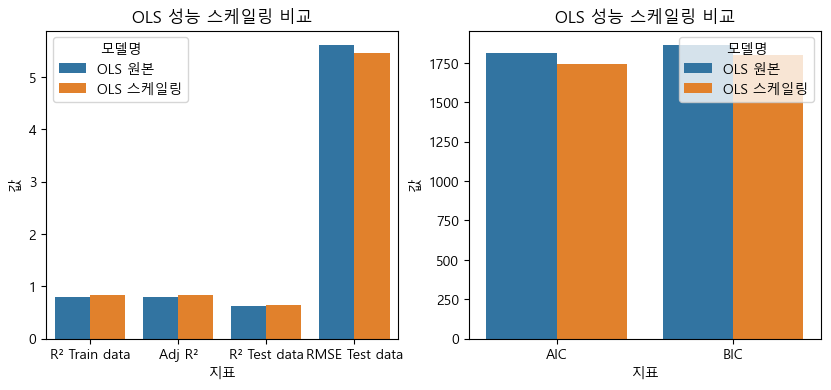

결과 출력
R² Train data     :    0.798 →    0.835 (↑ 향상, dif=0.037)
Adj R²            :    0.789 →    0.828 (↑ 향상, dif=0.039)
R² Test data      :    0.627 →    0.646 (↑ 향상, dif=0.019)
RMSE Test data    :    5.608 →    5.461 (↓ 감소, dif=-0.147)
AIC               : 1808.638 → 1744.903 (↓ 감소, dif=-63.736)
BIC               : 1861.174 → 1797.439 (↓ 감소, dif=-63.736)
- R², Adj R² 값이 높을수록 모델 좋음
- RMSE, AIC, BIC 값이 낮을수록 성능 좋음


In [86]:
results = {
    "모델명": ["OLS 원본", "OLS 스케일링"],
    "R² Train data": [ols_origin.rsquared, ols_test_scaled.rsquared],
    "Adj R²": [ols_origin.rsquared_adj, ols_test_scaled.rsquared_adj],
    "R² Test data" : [r2_ols_origin, r2_ols_test_scaled],
    "RMSE Test data": [rmse_ols_origin, rmse_ols_test_scaled],
    "AIC": [ols_origin.aic, ols_test_scaled.aic],
    "BIC": [ols_origin.bic, ols_test_scaled.bic],
}
compare_df = pd.DataFrame(results)
plot1 = compare_df.melt(id_vars="모델명",
                        value_vars=["R² Train data", "Adj R²", "R² Test data", "RMSE Test data"],
                        var_name="지표", value_name="값")

plot2 = compare_df.melt(id_vars="모델명",
                        value_vars=["AIC", "BIC"],
                        var_name="지표", value_name="값")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=plot1, x="지표", y="값", hue="모델명", ax=axes[0])
axes[0].set_title("OLS 성능 스케일링 비교")

sns.barplot(data=plot2, x="지표", y="값", hue="모델명", ax=axes[1])
axes[1].set_title("OLS 성능 스케일링 비교")
plt.show()

print("결과 출력")
for col in compare_df.columns[1:]:
    val1 = compare_df.loc[0, col]
    val2 = compare_df.loc[1, col]
    diff = val2 - val1
    trend = "↑ 향상" if diff > 0 else "↓ 감소" if diff < 0 else "-"
    print(f"{col:<18}: {val1:>8.3f} → {val2:>8.3f} ({trend}, dif={diff:.3f})")

print("- R², Adj R² 값이 높을수록 모델 좋음")
print("- RMSE, AIC, BIC 값이 낮을수록 성능 좋음")

# 2-2. 데이터 스케일링

In [89]:
# 독립변수, 종속변수 분리
x = df.drop(columns=["MEDV"])
y = df["MEDV"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# CHAS 는 0 / 1 형태의 자료이기 때문에 스케일링에서 제외하고 나중에 추가
x_cols = [c for c in df.columns if c not in ["MEDV", "CHAS"]]

chas_train = x_train["CHAS"].reset_index(drop=True)
chas_test  = x_test["CHAS"].reset_index(drop=True)

# CHAS 제외
x_train = x_train.drop(columns=["CHAS"]).reset_index(drop = True)
x_test = x_test.drop(columns=["CHAS"]).reset_index(drop = True)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

In [90]:
# 표준화
x_train_std = (x_train - x_train.mean()) / x_train.std(ddof=0)
x_test_std  = (x_test - x_train.mean()) / x_train.std(ddof=0)
x_train_std.columns = [f"{c}_std" for c in x_cols]
x_test_std.columns  = [f"{c}_std" for c in x_cols] 

In [91]:
# 로그변환
x_train_log = np.log1p(x_train.clip(lower=0))
x_test_log  = np.log1p(x_test.clip(lower=0))
x_train_log.columns = [f"{c}_log" for c in x_cols]
x_test_log.columns  = [f"{c}_log" for c in x_cols]


In [92]:
# 정규화 min-max 스케일링
xmin = x_train.min()
xmax = x_train.max()
x_train_mm = (x_train - xmin) / (xmax - xmin)
x_test_mm  = (x_test - xmin) / (xmax - xmin)

x_train_mm.columns = [f"{c}_mm" for c in x_cols]
x_test_mm.columns  = [f"{c}_mm" for c in x_cols]

In [93]:
# 제곱항
x_train_sq = x_train ** 2
x_test_sq  = x_test ** 2
x_train_sq.columns = [f"{c}_sq" for c in x_cols]
x_test_sq.columns  = [f"{c}_sq" for c in x_cols]

In [96]:
# CHAS 다시 추가
x_train["CHAS"] = chas_train
x_test["CHAS"]  = chas_test
x_cols.append("CHAS")

x_train_all = pd.concat([x_train,x_train_std.reset_index(drop=True),
                         x_train_log.reset_index(drop=True),
                         x_train_mm.reset_index(drop=True),
                         x_train_sq.reset_index(drop=True)], axis=1)

x_test_all = pd.concat([x_test.reset_index(drop=True),
                        x_test_std.reset_index(drop=True),
                        x_test_log.reset_index(drop=True),
                        x_test_mm.reset_index(drop=True),
                        x_test_sq.reset_index(drop=True)], axis=1)

print("원본 특성 수:", len(x_cols))
print("확장된 특성 수:", x_train_all.shape[1])

x_train_sm = sm.add_constant(x_train_all)
x_test_sm  = sm.add_constant(x_test_all, has_constant="add")

원본 특성 수: 14
확장된 특성 수: 61


# 2-3. 스케일링 후 데이터의 성능 평가

In [97]:
ols_scaled = sm.OLS(y_train, x_train_sm).fit()
print(ols_scaled.summary())

# 성능 평가
y_pred = ols_scaled.predict(x_test_sm)
rmse_ols_scaled = np.sqrt(np.mean((y_test - y_pred)**2))
r2_ols_scaled = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"RMSE: {rmse_ols_scaled:.4f}")
print(f"R²  : {r2_ols_scaled:.4f}")



                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     61.94
Date:                Mon, 13 Oct 2025   Prob (F-statistic):          9.22e-113
Time:                        20:20:10   Log-Likelihood:                -791.15
No. Observations:                 315   AIC:                             1658.
Df Residuals:                     277   BIC:                             1801.
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.4275      8.293      0.172      

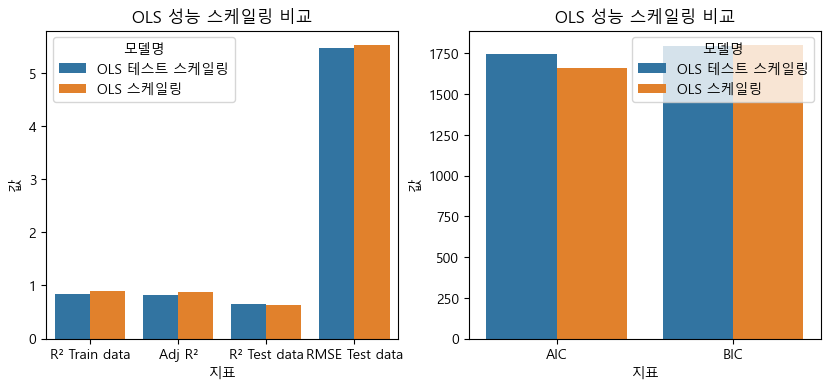

결과 출력
R² Train data     :    0.835 →    0.892 (↑ 향상, dif=0.057)
Adj R²            :    0.828 →    0.878 (↑ 향상, dif=0.050)
R² Test data      :    0.646 →    0.638 (↓ 감소, dif=-0.008)
RMSE Test data    :    5.461 →    5.522 (↑ 향상, dif=0.061)
AIC               : 1744.903 → 1658.305 (↓ 감소, dif=-86.597)
BIC               : 1797.439 → 1800.903 (↑ 향상, dif=3.464)
- R², Adj R² 값이 높을수록 모델 좋음
- RMSE, AIC, BIC 값이 낮을수록 성능 좋음


In [99]:
results = {
    "모델명": ["OLS 테스트 스케일링", "OLS 스케일링"],
    "R² Train data": [ols_test_scaled.rsquared, ols_scaled.rsquared],
    "Adj R²": [ols_test_scaled.rsquared_adj, ols_scaled.rsquared_adj],
    "R² Test data" : [r2_ols_test_scaled, r2_ols_scaled],
    "RMSE Test data": [rmse_ols_test_scaled, rmse_ols_scaled],
    "AIC": [ols_test_scaled.aic, ols_scaled.aic],
    "BIC": [ols_test_scaled.bic, ols_scaled.bic],
}
compare_df = pd.DataFrame(results)
plot1 = compare_df.melt(id_vars="모델명",
                        value_vars=["R² Train data", "Adj R²", "R² Test data", "RMSE Test data"],
                        var_name="지표", value_name="값")

plot2 = compare_df.melt(id_vars="모델명",
                        value_vars=["AIC", "BIC"],
                        var_name="지표", value_name="값")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=plot1, x="지표", y="값", hue="모델명", ax=axes[0])
axes[0].set_title("OLS 성능 스케일링 비교")

sns.barplot(data=plot2, x="지표", y="값", hue="모델명", ax=axes[1])
axes[1].set_title("OLS 성능 스케일링 비교")
plt.show()

print("결과 출력")
for col in compare_df.columns[1:]:
    val1 = compare_df.loc[0, col]
    val2 = compare_df.loc[1, col]
    diff = val2 - val1
    trend = "↑ 향상" if diff > 0 else "↓ 감소" if diff < 0 else "-"
    print(f"{col:<18}: {val1:>8.3f} → {val2:>8.3f} ({trend}, dif={diff:.3f})")

print("- R², Adj R² 값이 높을수록 모델 좋음")
print("- RMSE, AIC, BIC 값이 낮을수록 성능 좋음")

# 3. 데이터 선택 Stepwise와 규제 기법

# 3-1. 전진 선택법과 후진 제거법

In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)
base = LinearRegression()

best_k, best_score, best_selector = None, -np.inf, None

# 전진 선택법
for k in range(1, x_train_all.shape[1]):
    sfs_forward = SequentialFeatureSelector(
        base, n_features_to_select=k, direction="forward", scoring="r2", cv=cv)
    sfs_forward.fit(x_train_all, y_train)
    forward_cols = x_train_all.columns[sfs_forward.get_support()]
    score = cross_val_score(base, x_train_all[forward_cols], y_train, scoring="r2", cv=cv).mean()
    
    if score > best_score:
        best_k, best_score, best_selector = k, score, sfs_forward

best_forward = list(x_train_all.columns[best_selector.get_support()])
print("전진 선택법")
print("최적 k:", best_k)
print("CV R2:", round(best_score, 4))
print("선택된 컬럼:", list(x_train_all.columns[best_selector.get_support()]))

best_k, best_score, best_selector = None, -np.inf, None

# 후진 제거법
for k in range(1, x_train_all.shape[1]):
    sfs_backward = SequentialFeatureSelector(
        base, n_features_to_select=k, direction="backward", scoring="r2", cv=cv)
    sfs_backward.fit(x_train_all, y_train)
    backward_cols = x_train_all.columns[sfs_backward.get_support()]
    score = cross_val_score(base, x_train_all[backward_cols], y_train, scoring="r2", cv=cv).mean()
    
    if score > best_score:
        best_k, best_score, best_selector = k, score, sfs_backward

print("최적 k:", best_k)
print("CV R2:", round(best_score, 4))
best_backward = list(x_train_all.columns[best_selector.get_support()])
print("선택된 컬럼:",best_backward)


전진 선택법
최적 k: 20
CV R2: 0.8414
선택된 컬럼: ['CRIM', 'RM', 'DIS', 'TAX', 'CRIM_std', 'RM_std', 'DIS_std', 'TAX_std', 'PTRATIO_log', 'LSTAT_log', 'CRIM_mm', 'RM_mm', 'DIS_mm', 'TAX_mm', 'NOX_sq', 'RM_sq', 'DIS_sq', 'RAD_sq', 'PTRATIO_sq', 'B_sq']
최적 k: 16
CV R2: 0.8446
선택된 컬럼: ['DIS', 'TAX', 'PTRATIO', 'NOX_std', 'RM_std', 'RAD_std', 'ZN_log', 'TAX_log', 'PTRATIO_log', 'LSTAT_log', 'CRIM_mm', 'ZN_mm', 'B_mm', 'ZN_sq', 'RM_sq', 'TAX_sq']


# 최적 변수 데이터의 성능 평가

In [101]:
X_train_sm2 = sm.add_constant(x_train_sm[best_forward])
X_test_sm2 = sm.add_constant(x_test_sm[best_forward])

ols_stepwise_scaled = sm.OLS(y_train, X_train_sm2).fit()
print(ols_stepwise_scaled.summary())

# 성능 평가
y_pred = ols_stepwise_scaled.predict(X_test_sm2)
rmse_ols_stepwise_scaled = np.sqrt(np.mean((y_test - y_pred)**2))
r2_ols_stepwise_scaled = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"RMSE: {rmse_ols_stepwise_scaled:.4f}")
print(f"R²  : {r2_ols_stepwise_scaled:.4f}")

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                     169.5
Date:                Mon, 13 Oct 2025   Prob (F-statistic):          2.49e-126
Time:                        21:18:12   Log-Likelihood:                -819.70
No. Observations:                 315   AIC:                             1665.
Df Residuals:                     302   BIC:                             1714.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.6404      1.004      2.630      

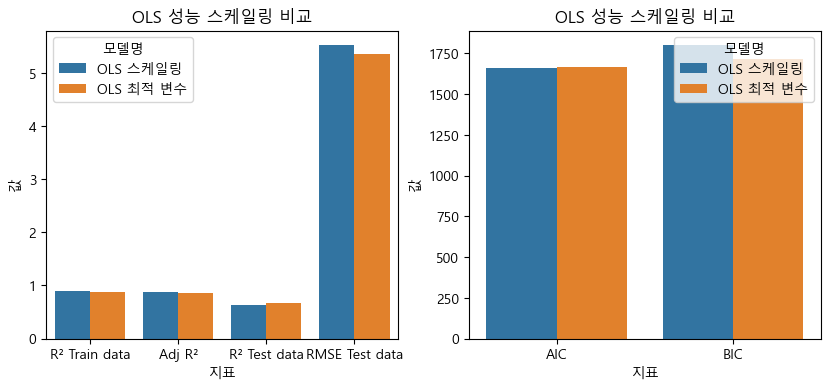

결과 출력
R² Train data     :    0.892 →    0.871 (↓ 감소, dif=-0.021)
Adj R²            :    0.878 →    0.866 (↓ 감소, dif=-0.012)
R² Test data      :    0.638 →    0.660 (↑ 향상, dif=0.022)
RMSE Test data    :    5.522 →    5.355 (↓ 감소, dif=-0.168)
AIC               : 1658.305 → 1665.408 (↑ 향상, dif=7.103)
BIC               : 1800.903 → 1714.192 (↓ 감소, dif=-86.711)
- R², Adj R² 값이 높을수록 모델 좋음
- RMSE, AIC, BIC 값이 낮을수록 성능 좋음


In [102]:
results = {
    "모델명": ["OLS 스케일링", "OLS 최적 변수"],
    "R² Train data": [ols_scaled.rsquared, ols_stepwise_scaled.rsquared],
    "Adj R²": [ols_scaled.rsquared_adj, ols_stepwise_scaled.rsquared_adj],
    "R² Test data" : [r2_ols_scaled, r2_ols_stepwise_scaled],
    "RMSE Test data": [rmse_ols_scaled, rmse_ols_stepwise_scaled],
    "AIC": [ols_scaled.aic, ols_stepwise_scaled.aic],
    "BIC": [ols_scaled.bic, ols_stepwise_scaled.bic],
}
compare_df = pd.DataFrame(results)
plot1 = compare_df.melt(id_vars="모델명",
                        value_vars=["R² Train data", "Adj R²", "R² Test data", "RMSE Test data"],
                        var_name="지표", value_name="값")

plot2 = compare_df.melt(id_vars="모델명",
                        value_vars=["AIC", "BIC"],
                        var_name="지표", value_name="값")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=plot1, x="지표", y="값", hue="모델명", ax=axes[0])
axes[0].set_title("OLS 성능 스케일링 비교")

sns.barplot(data=plot2, x="지표", y="값", hue="모델명", ax=axes[1])
axes[1].set_title("OLS 성능 스케일링 비교")
plt.show()

print("결과 출력")
for col in compare_df.columns[1:]:
    val1 = compare_df.loc[0, col]
    val2 = compare_df.loc[1, col]
    diff = val2 - val1
    trend = "↑ 향상" if diff > 0 else "↓ 감소" if diff < 0 else "-"
    print(f"{col:<18}: {val1:>8.3f} → {val2:>8.3f} ({trend}, dif={diff:.3f})")

print("- R², Adj R² 값이 높을수록 모델 좋음")
print("- RMSE, AIC, BIC 값이 낮을수록 성능 좋음")

# 3-2. 규제 기법

In [103]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# 규제 모델 정의
ridge = Ridge(alpha=1.0, max_iter=10000).fit(x_train_all, y_train)          # Ridge L2 규제
lasso = Lasso(alpha=0.1, max_iter=10000).fit(x_train_all, y_train)          # Lasso L1 규제
enet  = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000).fit(x_train_all, y_train)   # ElasticNet

# 성능 출력
def report(model, name):
    y_pred = model.predict(x_test_all)
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
    print(f"[{name}]")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")

# 각 규제 모델에 맞게 RMSE 와 R2를 출력확인
report(ridge, "Ridge")                  
report(lasso, "Lasso")
report(enet, "ElasticNet")

# 계수 비교
coef_df = pd.DataFrame({
    "feature": x_test_all.columns,
    "ridge": ridge.coef_,
    "lasso": lasso.coef_,
    "elasticnet": enet.coef_
})
print("\n[계수 비교]")
print(coef_df.to_string(index=False))


[Ridge]
RMSE: 5.2402
R²  : 0.6744
[Lasso]
RMSE: 5.5929
R²  : 0.6291
[ElasticNet]
RMSE: 5.5495
R²  : 0.6349

[계수 비교]
    feature         ridge     lasso  elasticnet
       CRIM -3.734633e-01 -0.244440   -0.247126
         ZN -2.847905e-01 -0.052898   -0.127723
      INDUS  1.948537e-01 -0.324706   -0.384749
        NOX -2.497965e-01 -0.000000   -0.000000
         RM -4.469952e+00 -0.000000   -0.301841
        AGE  3.588400e-03  0.032712    0.030493
        DIS -1.776840e+00 -0.999490   -0.992825
        RAD  2.701618e-01  0.384836    0.401655
        TAX  2.777001e-04 -0.011081   -0.007737
    PTRATIO -2.559178e+00 -0.000000   -0.021298
          B  2.273417e-02  0.016354    0.016351
      LSTAT -1.784864e-01 -1.440341   -1.371748
       CHAS  1.812883e+00  0.305581    0.624832
   CRIM_std -3.833300e-02 -0.000000   -0.000000
     ZN_std -1.240524e-02 -0.000000   -0.000000
  INDUS_std  2.844000e-02 -0.000000   -0.000000
    NOX_std -2.153352e+00 -1.157761   -1.163466
     RM_std -6.35156

In [104]:
# OLS 모델의 k-fold 5회 평균 R2 모델 성능평가
cv = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()
scores = cross_val_score(model, x_train_all, y_train, cv=cv, scoring="r2")
print("각 fold별 R²:", scores)
print("평균 R²:", np.mean(scores))

각 fold별 R²: [0.6856161  0.91207282 0.87702088 0.69529142 0.86107306]
평균 R²: 0.806214857923918


# 4. Grid Search

In [105]:
# Grid Search와 CV를 통해 하이퍼파라미터를 탐색

from sklearn.model_selection import GridSearchCV

# alpha를 로그스케일로 폭넓게 탐색
alphas = np.logspace(-3, 2, 20)  # 0.001 ~ 100

# Ridge, Lasso, ElasticNet 모델과 파라미터
ridge_grid = {"alpha":  np.logspace(-6, 6, 100)}     # 1e-6 ~ 1e6
lasso_grid = {"alpha":  np.logspace(-6, 6, 100)}     # 1e-6 ~ 1e6
enet_grid  = {
    "alpha":   np.logspace(-6, 6, 100),              # 1e-6 ~ 1e6
    "l1_ratio":[0.2, 0.5, 0.8, 0.95, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3) GridSearchCV 각각 실행
ridge = GridSearchCV(Ridge(), ridge_grid, cv=5)
lasso = GridSearchCV(Lasso(), lasso_grid, cv=5)
enet  = GridSearchCV(ElasticNet(), enet_grid, cv=5)

ridge.fit(x_train_all, y_train)
lasso.fit(x_train_all, y_train)
enet.fit(x_train_all, y_train)

# 결과 출력
print("Best Ridge:", ridge.best_params_, "Score:", ridge.best_score_)
print("Best Lasso:", lasso.best_params_, "Score:", lasso.best_score_)
print("Best ElasticNet:", enet.best_params_, "Score:", enet.best_score_)

# 최적 모델로 Test 평가
best_models = {
    "Ridge": ridge.best_estimator_,
    "Lasso": lasso.best_estimator_,
    "ElasticNet": enet.best_estimator_
}

for name, model in best_models.items():
    y_pred = model.predict(x_test_all)
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
    print(f"{name} Test RMSE: {rmse:.3f}")
    print(f"{name} Test R2: {r2:.3f}")

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.10423e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.09062e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.05913e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.10734e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=

Best Ridge: {'alpha': np.float64(0.00572236765935022)} Score: 0.8424130586060322
Best Lasso: {'alpha': np.float64(1e-06)} Score: 0.8437508352788875
Best ElasticNet: {'alpha': np.float64(1e-06), 'l1_ratio': 1.0} Score: 0.8437508352788875
Ridge Test RMSE: 5.472
Ridge Test R2: 0.645
Lasso Test RMSE: 5.427
Lasso Test R2: 0.651
ElasticNet Test RMSE: 5.427
ElasticNet Test R2: 0.651


c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.439e+03, tolerance: 2.598e+00
  model = cd_fast.enet_coordinate_descent(


In [106]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# 규제 모델 정의
ridge = Ridge(alpha=np.float64(1e-06)).fit(x_train_all, y_train)
lasso = Lasso(alpha=np.float64(0.007564633275546291)).fit(x_train_all, y_train)
enet  = ElasticNet(alpha=np.float64(0.00572236765935022), l1_ratio=0.8).fit(x_train_all, y_train)

# 성능 출력
def report(model, name):
    y_pred = model.predict(x_test_all)
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)
    print(f"[{name}]")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")

report(ridge, "Ridge")
report(lasso, "Lasso")
report(enet, "ElasticNet")

# 계수 비교
coef_df = pd.DataFrame({
    "feature": x_test_all.columns,
    "ridge": ridge.coef_,
    "lasso": lasso.coef_,
    "elasticnet": enet.coef_
})
print("\n[계수 비교]")
print(coef_df.to_string(index=False))

[Ridge]
RMSE: 5.5277
R²  : 0.6377
[Lasso]
RMSE: 5.2428
R²  : 0.6741
[ElasticNet]
RMSE: 5.2220
R²  : 0.6767

[계수 비교]
    feature       ridge      lasso  elasticnet
       CRIM   -0.299384  -0.306064   -0.328463
         ZN   -0.285562  -0.284923   -0.285986
      INDUS    0.688572   0.299836    0.246217
        NOX  -13.049669  -0.000000   -0.000000
         RM   15.852128  -7.327199   -4.167215
        AGE   -0.053834  -0.009116   -0.015145
        DIS   -5.234129  -1.299315   -1.220655
        RAD    0.989646  -0.525522   -0.451636
        TAX    0.272826  -0.007535   -0.008071
    PTRATIO    3.593659  -3.849637   -3.394407
          B    0.022723   0.022036    0.024778
      LSTAT    0.938402   0.240612    0.026658
       CHAS    1.686234   1.706429    1.751681
   CRIM_std   -0.030734  -0.000000   -0.000000
     ZN_std   -0.012442   0.000000    0.000000
  INDUS_std    0.100479  -0.000000   -0.000000
    NOX_std -112.493685  -2.290621   -2.299916
     RM_std   22.525044  -5.802042   -

c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.6495e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.596e+03, tolerance: 2.598e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\a6742\anaconda3\envs\BigDataClass\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.596e+03, tolerance: 2.598e+00
  model = cd_fast.enet_coordinate_descent(
